In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [12]:
df = pd.read_csv("../data/raw/PRDECT-ID_Dataset.csv")

In [20]:
print("Shape:", df.shape)
df.head(5)

Shape: (5400, 11)


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,happy


In [21]:
print("Columns:", df.columns.tolist())
print()
df.dtypes

Columns: ['Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 'Sentiment', 'Emotion']



Category            object
Product Name        object
Location            object
Price                int64
Overall Rating     float64
Number Sold          int64
Total Review         int64
Customer Rating      int64
Customer Review     object
Sentiment           object
Emotion             object
dtype: object

In [22]:
df.isnull().sum()

Category           0
Product Name       0
Location           0
Price              0
Overall Rating     0
Number Sold        0
Total Review       0
Customer Rating    0
Customer Review    0
Sentiment          0
Emotion            0
dtype: int64

In [23]:
print("Fully duplicate rows:", df.duplicated().sum())
print("Duplicate Customer Reviews:", df["Customer Review"].duplicated().sum())

Fully duplicate rows: 7
Duplicate Customer Reviews: 95


In [29]:
emotion_order = df["Emotion"].value_counts().index.tolist()
colors = sns.color_palette("muted", n_colors=len(emotion_order))
emotion_counts = df["Emotion"].value_counts()
print(emotion_counts)
print("\nProportions:")
print((emotion_counts / len(df)).round(3))

Emotion
happy      1770
sadness    1202
fear        920
love        809
anger       699
Name: count, dtype: int64

Proportions:
Emotion
happy      0.328
sadness    0.223
fear       0.170
love       0.150
anger      0.129
Name: count, dtype: float64


Text(0.98, 0.95, 'Max/min imbalance ratio: 2.53x (happy vs anger)')

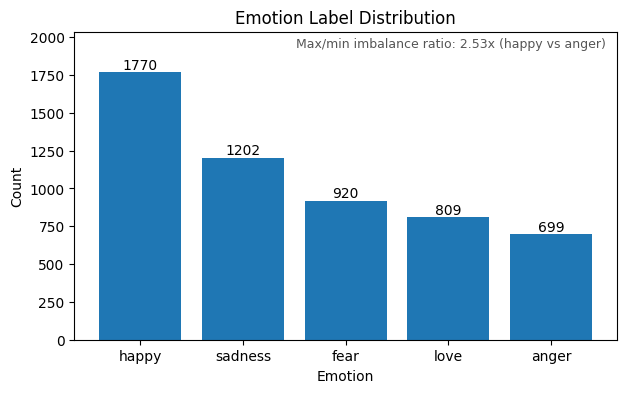

In [32]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(emotion_counts.index, emotion_counts.values)
ax.bar_label(bars)
ax.set_title('Emotion Label Distribution')
ax.set_xlabel('Emotion')
ax.set_ylabel('Count')
ax.set_ylim(0, emotion_counts.max() * 1.15)

ratio = emotion_counts.max() / emotion_counts.min()
ax.annotate(f"Max/min imbalance ratio: {ratio:.2f}x ({emotion_counts.idxmax()} vs {emotion_counts.idxmin()})",
            xy=(0.98, 0.95), xycoords="axes fraction",
            ha="right", fontsize=9, color="#555")


sentiment is a binary collapse of emotion. no independent information, exclude from model features. 

in here we can divide as happy + love = positive while sadness + anger + fear = negative

In [34]:
print(pd.crosstab(df["Emotion"], df["Sentiment"]))

Sentiment  Negative  Positive
Emotion                      
anger           699         0
fear            920         0
happy             0      1770
love              0       809
sadness        1202         0


In [39]:
df["word_count"] = df["Customer Review"].apply(lambda x: len(str(x).split()))
df["char_count"] = df["Customer Review"].apply(len)

print("Word count summary:")
print(df["word_count"].describe().round(2))

Word count summary:
count    5400.00
mean       16.10
std        15.65
min         1.00
25%         7.00
50%        12.00
75%        20.00
max       184.00
Name: word_count, dtype: float64


C:\Users\zahra\AppData\Local\Temp\ipykernel_8160\557987377.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_for_box, labels=emotion_order, patch_artist=True,


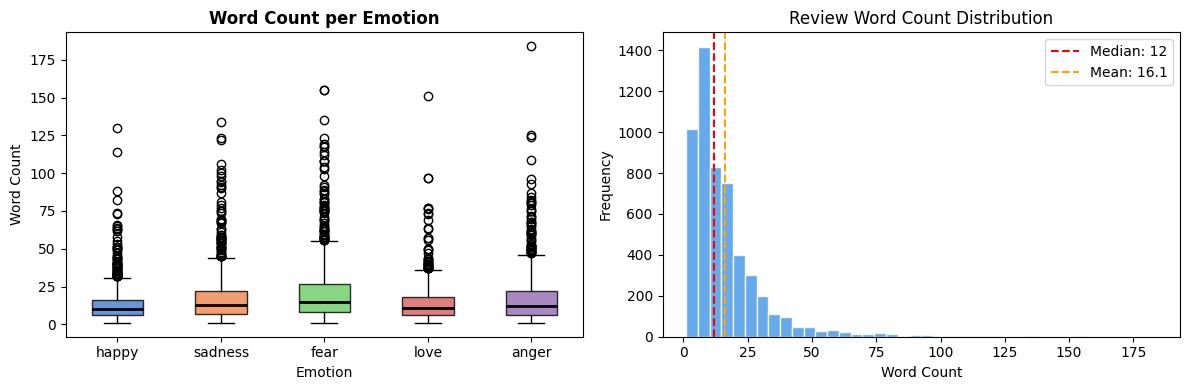

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot per emotion
data_for_box = [df[df["Emotion"] == em]["word_count"].values for em in emotion_order]
bp = axes[0].boxplot(data_for_box, labels=emotion_order, patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_title("Word Count per Emotion", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Word Count")

# Histogram
axes[1].hist(df["word_count"], bins=40, color="#4C9BE8", edgecolor="white", alpha=0.85)
axes[1].axvline(df["word_count"].median(), color="red", linestyle="--", linewidth=1.5,
                label=f"Median: {df['word_count'].median():.0f}")
axes[1].axvline(df["word_count"].mean(), color="orange", linestyle="--", linewidth=1.5,
                label=f"Mean: {df['word_count'].mean():.1f}")
axes[1].legend()
axes[1].set_title("Review Word Count Distribution", fontsize=12)
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [41]:
print("Sample reviews per emotion:")
print("-" * 70)
for em in emotion_order:
    sample = df[df["Emotion"] == em]["Customer Review"].iloc[0]
    print(f"[{em}]  {sample[:150]}")
    print()

Sample reviews per emotion:
----------------------------------------------------------------------
[happy]  Alhamdulillah berfungsi dengan baik. Packaging aman. Respon cepat dan ramah. Seller dan kurir amanah

[sadness]  Sangat kecewa. Baru 4 bulan scroll sudah rusak.

[fear]  BAHAN DARI PLASTIK DAN TIDAK KUAT JUGA BUAT MENOPANG LAPTOP.INI SIH KUATNYA BUAT TABLET GAISSS. LEBIH BAIK JANGAN BELI YANG INI

[love]  Bagus banget keyboardnya. Packing sangat aman karena double kardus. Warna juga keren.

[anger]  Sangat mengecewakan, barang yg dikirim tidak sesuai konfirmasi, sampai harus bolak-balik 2 kali, saya harus nanggung 6 X ongkos kirim....SANGAT MENGEC



In [42]:
# Rough code-switching detector
common_english = {"the", "is", "are", "was", "this", "good", "great", "nice",
                  "very", "not", "with", "ok", "seller", "product", "item",
                  "quality", "fast", "recommended", "original", "packaging"}

def has_english(text):
    tokens = set(str(text).lower().split())
    return len(tokens & common_english) > 0

mixed = df["Customer Review"].apply(has_english)
print(f"Reviews with English tokens (code-switching estimate): {mixed.sum()} ({mixed.mean()*100:.1f}%)")

Reviews with English tokens (code-switching estimate): 870 (16.1%)


In [43]:
print(pd.crosstab(df["Emotion"], df["Customer Rating"]))

Customer Rating    1    2    3    4     5
Emotion                                  
anger            575   75   45    2     2
fear             590  198  129    3     0
happy              0    0   54  352  1364
love               0    0    3   25   781
sadness          667  288  231   13     3


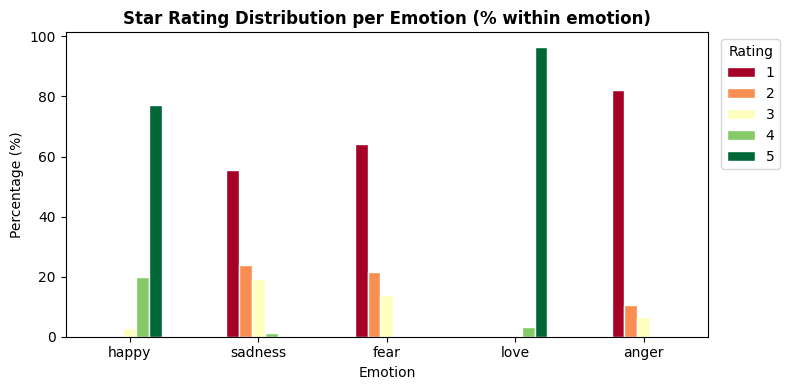

High star ratings align strongly with Happy/Love.
1-star ratings dominate Anger/Sadness/Fear. Label quality looks consistent.


In [44]:
rating_emotion = pd.crosstab(df["Emotion"], df["Customer Rating"])
rating_pct = rating_emotion.div(rating_emotion.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 4))
rating_pct[sorted(rating_pct.columns)].loc[emotion_order].plot(
    kind="bar", ax=ax, colormap="RdYlGn", edgecolor="white"
)
ax.set_title("Star Rating Distribution per Emotion (% within emotion)", fontsize=12, fontweight="bold")
ax.set_xlabel("Emotion")
ax.set_ylabel("Percentage (%)")
ax.set_xticklabels(emotion_order, rotation=0)
ax.legend(title="Rating", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("High star ratings align strongly with Happy/Love.")
print("1-star ratings dominate Anger/Sadness/Fear. Label quality looks consistent.")

In [45]:
limited = df.groupby("Category")["Emotion"].nunique()
print("Categories with fewer than 5 emotion classes:")
print(limited[limited < 5])

Categories with fewer than 5 emotion classes:
Category
Precious Metal     2
Property           2
Tour and Travel    2
Name: Emotion, dtype: int64


In [49]:
print("Emotion class sizes:")
for em, count in emotion_counts.items():
    pct = count / len(df) * 100
    ratio_to_max = emotion_counts.max() / count
    print(f"  {em:<10} {count:>5}  ({pct:.1f}%)  --  {ratio_to_max:.2f}x smaller than largest class")

print(f"\nOverall max/min ratio: {emotion_counts.max() / emotion_counts.min():.2f}x")

Emotion class sizes:
  happy       1770  (32.8%)  --  1.00x smaller than largest class
  sadness     1202  (22.3%)  --  1.47x smaller than largest class
  fear         920  (17.0%)  --  1.92x smaller than largest class
  love         809  (15.0%)  --  2.19x smaller than largest class
  anger        699  (12.9%)  --  2.53x smaller than largest class

Overall max/min ratio: 2.53x
